In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import mlflow
import mlflow.pytorch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── PATHS ────────────────────────────────────────────────────
COMBINED_CSV = "/Users/aditibharadwaj/Documents/experiqs/MH_SOC/S2_timeseries_combined.csv"

# ── SEQUENCE CONFIG ──────────────────────────────────────────
# Fixed sequence length — shorter sequences get zero-padded,
# longer ones get the most-recent N observations kept.
SEQ_LEN = 48          # ~24 months at ~5-day Sentinel-2 revisit after cloud filter
BAND_COLS = ["B2", "B3", "B4", "B8", "B11", "B12"]
N_FEATURES = len(BAND_COLS)   # 6

# SCL values to keep (bare/clear observations only)
# 4=Vegetation, 5=Bare soil, 6=Water, 7=Unclassified
# Keep 4 and 5 — these are the most relevant for SOC
VALID_SCL = [4, 5]

# ── TRAINING CONFIG ──────────────────────────────────────────
BATCH_SIZE   = 64
HIDDEN_SIZE  = 128
NUM_LAYERS   = 2
DROPOUT      = 0.3
LEARNING_RATE = 1e-3
NUM_EPOCHS   = 50
PATIENCE     = 10        # early stopping
TEST_SIZE    = 0.15
VAL_SIZE     = 0.15
RANDOM_STATE = 42

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: mps


## Load & Inspect Data

In [3]:
df = pd.read_csv(COMBINED_CSV, low_memory=False)
df["tile_date"] = pd.to_datetime(df["tile_date"])
df["sample_date_clean"] = pd.to_datetime(df["sample_date_clean"])

print(f"Total rows:            {len(df):,}")
print(f"Unique sample points:  {df['id'].nunique():,}")
print(f"Avg obs per point:     {len(df) / df['id'].nunique():.1f}")
print(f"OC range:              {df['OC'].min():.3f} — {df['OC'].max():.3f}")
print(f"Date range:            {df['tile_date'].min().date()} to {df['tile_date'].max().date()}")
print(f"\nColumns: {list(df.columns)}")
df.head(3)

Total rows:            4,792,639
Unique sample points:  29,942
Avg obs per point:     160.1
OC range:              0.007 — 3.500
Date range:            2021-10-23 to 2025-09-07

Columns: ['id', 'lat_key', 'lon_key', 'sample_date_clean', 'OC', 'tile_date', 'days_from_sample', 'cloud_cover', 'SCL', 'B2', 'B3', 'B4', 'B8', 'B11', 'B12']


,id,lat_key,lon_key,sample_date_clean,OC,tile_date,days_from_sample,cloud_cover,SCL,B2,B3,B4,B8,B11,B12
0,Maha_OC_00000001,15.709677,74.047631,2025-02-17,1.59,2023-02-18,729.760687,1.025076,5.0,584.0,758.0,1064.0,2066.0,2814.0,1896.0
1,Maha_OC_00000001,15.709677,74.047631,2025-02-17,1.59,2023-02-23,724.760649,0.005438,5.0,580.0,754.0,1146.0,2188.0,3012.0,2099.0
2,Maha_OC_00000001,15.709677,74.047631,2025-02-17,1.59,2023-02-28,719.760679,0.000624,5.0,548.0,720.0,1010.0,2104.0,3049.0,2114.0


## Preprocessing

In [4]:
# ── 2a. SCL filtering (keep bare/vegetated only) ─────────────
before = len(df)
df = df[df["SCL"].isin(VALID_SCL)].copy()
print(f"After SCL filter: {len(df):,} rows (dropped {before - len(df):,})")

# ── 2b. Drop rows with missing band values ───────────────────
before = len(df)
df = df.dropna(subset=BAND_COLS).copy()
print(f"After band null drop: {len(df):,} rows (dropped {before - len(df):,})")

# ── 2c. Sort chronologically within each point ───────────────
df = df.sort_values(["id", "tile_date"]).reset_index(drop=True)

# ── 2d. Check observation counts per point ───────────────────
obs_counts = df.groupby("id").size()
print(f"\nObs per point — min: {obs_counts.min()}, "
      f"median: {obs_counts.median():.0f}, "
      f"max: {obs_counts.max()}")
print(f"Points with < 5 obs: {(obs_counts < 5).sum()}")

# Drop points with fewer than 5 observations — too sparse for LSTM
valid_ids = obs_counts[obs_counts >= 5].index
df = df[df["id"].isin(valid_ids)].copy()
print(f"Points remaining after min-obs filter: {df['id'].nunique():,}")

After SCL filter: 3,778,680 rows (dropped 1,013,959)
After band null drop: 3,778,662 rows (dropped 18)

Obs per point — min: 13, median: 90, max: 727
Points with < 5 obs: 0
Points remaining after min-obs filter: 29,942


In [5]:
# ── 2e. Scale band values ────────────────────────────────────
# Fit scaler on all band observations
scaler = StandardScaler()
df[BAND_COLS] = scaler.fit_transform(df[BAND_COLS])

# ── 2f. Build sequences ──────────────────────────────────────
# For each unique point: take the last SEQ_LEN observations.
# Zero-pad from the LEFT if fewer than SEQ_LEN obs exist.
def build_sequences(df, seq_len, band_cols):
    X_list, y_list, id_list = [], [], []
    for pt_id, group in df.groupby("id", sort=False):
        bands = group[band_cols].values.astype(np.float32)  # (T, 6)
        oc    = group["OC"].iloc[0].astype(np.float32)
        T = len(bands)
        if T >= seq_len:
            # Keep the most recent seq_len observations
            seq = bands[-seq_len:]
        else:
            # Left-pad with zeros
            pad = np.zeros((seq_len - T, len(band_cols)), dtype=np.float32)
            seq = np.vstack([pad, bands])
        X_list.append(seq)
        y_list.append(oc)
        id_list.append(pt_id)
    return np.stack(X_list), np.array(y_list, dtype=np.float32), id_list

X, y, ids = build_sequences(df, SEQ_LEN, BAND_COLS)
print(f"X shape: {X.shape}  →  (n_points, seq_len, n_features)")
print(f"y shape: {y.shape}")
print(f"y range: {y.min():.3f} — {y.max():.3f}")

X shape: (29942, 48, 6)  →  (n_points, seq_len, n_features)
y shape: (29942,)
y range: 0.007 — 3.500


In [6]:
# ── 2g. Train / Val / Test split (point-level, not row-level) ─
ids_arr = np.array(ids)
idx = np.arange(len(X))

idx_train, idx_test = train_test_split(idx, test_size=TEST_SIZE, random_state=RANDOM_STATE)
idx_train, idx_val  = train_test_split(idx_train, test_size=VAL_SIZE/(1-TEST_SIZE), random_state=RANDOM_STATE)

X_train, y_train = X[idx_train], y[idx_train]
X_val,   y_val   = X[idx_val],   y[idx_val]
X_test,  y_test  = X[idx_test],  y[idx_test]

print(f"Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")

Train: 20,958  Val: 4,492  Test: 4,492


## Dataset & DataLoader

In [7]:
class SOCDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(SOCDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(SOCDataset(X_val,   y_val),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(SOCDataset(X_test,  y_test),  batch_size=BATCH_SIZE)
print("DataLoaders ready")

DataLoaders ready


## Model Definition

In [8]:
class SOC_LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x: (batch, seq_len, n_features)
        out, _ = self.lstm(x)        # (batch, seq_len, hidden)
        out = self.dropout(out[:, -1, :])  # last timestep
        return self.fc(out)          # (batch, 1)

model = SOC_LSTM(N_FEATURES, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

SOC_LSTM(
  (lstm): LSTM(6, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

Trainable parameters: 210,049


## Training with MLflow

In [12]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    preds, targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            out = model(X_batch)
            total_loss += criterion(out, y_batch).item() * len(X_batch)
            preds.extend(out.cpu().numpy().flatten())
            targets.extend(y_batch.cpu().numpy().flatten())
    avg_loss = total_loss / len(loader.dataset)
    preds, targets = np.array(preds), np.array(targets)
    return avg_loss, preds, targets


mlflow.set_experiment("SOC_RF_Tabular")

with mlflow.start_run(run_name="LSTM_S2_timeseries"):

    # ── Log hyperparameters ──────────────────────────────────
    mlflow.log_params({
        "model":          "LSTM",
        "seq_len":        SEQ_LEN,
        "n_features":     N_FEATURES,
        "hidden_size":    HIDDEN_SIZE,
        "num_layers":     NUM_LAYERS,
        "dropout":        DROPOUT,
        "learning_rate":  LEARNING_RATE,
        "batch_size":     BATCH_SIZE,
        "num_epochs":     NUM_EPOCHS,
        "patience":       PATIENCE,
        "valid_scl":      str(VALID_SCL),
        "n_train":        len(X_train),
        "n_val":          len(X_val),
        "n_test":         len(X_test),
    })

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )

    best_val_loss = float("inf")
    patience_counter = 0
    train_losses, val_losses = [], []

    for epoch in range(1, NUM_EPOCHS + 1):
        # ── Train ────────────────────────────────────────────
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item() * len(X_batch)
        train_loss = epoch_loss / len(train_loader.dataset)

        # ── Validate ─────────────────────────────────────────
        val_loss, val_preds, val_targets = evaluate(model, val_loader, criterion, DEVICE)
        val_r2   = r2_score(val_targets, val_preds)
        val_mae  = mean_absolute_error(val_targets, val_preds)
        val_rmse = np.sqrt(mean_squared_error(val_targets, val_preds))

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        mlflow.log_metric("learning_rate", current_lr, step=epoch)

        # ── MLflow per-epoch metrics ─────────────────────────
        mlflow.log_metrics({
            "train_loss": train_loss,
            "val_loss":   val_loss,
            "val_r2":     val_r2,
            "val_mae":    val_mae,
            "val_rmse":   val_rmse,
        }, step=epoch)

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d} | "
                  f"Train MSE: {train_loss:.4f} | "
                  f"Val MSE: {val_loss:.4f} | "
                  f"Val R²: {val_r2:.4f} | "
                  f"Val RMSE: {val_rmse:.4f}")

        # ── Early stopping ───────────────────────────────────
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "best_lstm_soc.pt")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"Early stopping at epoch {epoch}")
                break

    # ── Test evaluation ──────────────────────────────────────
    model.load_state_dict(torch.load("best_lstm_soc.pt", weights_only=True))
    test_loss, test_preds, test_targets = evaluate(model, test_loader, criterion, DEVICE)
    test_r2   = r2_score(test_targets, test_preds)
    test_mae  = mean_absolute_error(test_targets, test_preds)
    test_rmse = np.sqrt(mean_squared_error(test_targets, test_preds))

    mlflow.log_metrics({
        "test_loss": test_loss,
        "test_r2":   test_r2,
        "test_mae":  test_mae,
        "test_rmse": test_rmse,
    })

    # ── Log model ────────────────────────────────────────────
    mlflow.pytorch.log_model(model, "lstm_soc_model")

    print(f"\n── Test Results ──────────────────")
    print(f"R²:   {test_r2:.4f}")
    print(f"RMSE: {test_rmse:.4f}")
    print(f"MAE:  {test_mae:.4f}")

Epoch   1 | Train MSE: 0.1601 | Val MSE: 0.1691 | Val R²: 0.1003 | Val RMSE: 0.4112
Epoch   5 | Train MSE: 0.1471 | Val MSE: 0.1532 | Val R²: 0.1850 | Val RMSE: 0.3914
Epoch  10 | Train MSE: 0.1357 | Val MSE: 0.1580 | Val R²: 0.1593 | Val RMSE: 0.3975
Epoch  15 | Train MSE: 0.1249 | Val MSE: 0.1362 | Val R²: 0.2753 | Val RMSE: 0.3691
Epoch  20 | Train MSE: 0.1164 | Val MSE: 0.1313 | Val R²: 0.3013 | Val RMSE: 0.3624
Epoch  25 | Train MSE: 0.1128 | Val MSE: 0.1260 | Val R²: 0.3296 | Val RMSE: 0.3550
Epoch  30 | Train MSE: 0.1077 | Val MSE: 0.1245 | Val R²: 0.3379 | Val RMSE: 0.3528
Epoch  35 | Train MSE: 0.1008 | Val MSE: 0.1270 | Val R²: 0.3244 | Val RMSE: 0.3564
Epoch  40 | Train MSE: 0.0958 | Val MSE: 0.1227 | Val R²: 0.3471 | Val RMSE: 0.3503
Epoch  45 | Train MSE: 0.0887 | Val MSE: 0.1276 | Val R²: 0.3210 | Val RMSE: 0.3572
Epoch  50 | Train MSE: 0.0866 | Val MSE: 0.1222 | Val R²: 0.3496 | Val RMSE: 0.3496


2026/06/22 09:49:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/22 09:49:50 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.



── Test Results ──────────────────
R²:   0.3753
RMSE: 0.3476
MAE:  0.2189


## 6. Diagnostics

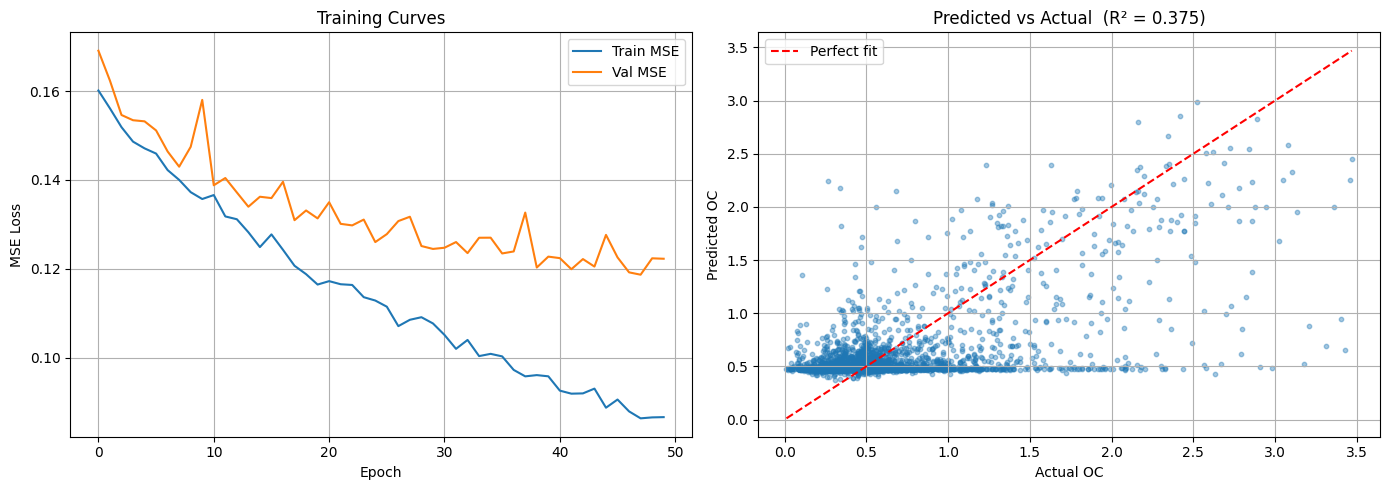

Saved: lstm_soc_diagnostics.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(train_losses, label="Train MSE")
axes[0].plot(val_losses,   label="Val MSE")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Training Curves")
axes[0].legend()
axes[0].grid(True)

# Predicted vs Actual
axes[1].scatter(test_targets, test_preds, alpha=0.4, s=10)
mn, mx = test_targets.min(), test_targets.max()
axes[1].plot([mn, mx], [mn, mx], "r--", label="Perfect fit")
axes[1].set_xlabel("Actual OC")
axes[1].set_ylabel("Predicted OC")
axes[1].set_title(f"Predicted vs Actual  (R² = {test_r2:.3f})")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("lstm_soc_diagnostics.png", dpi=150)
plt.show()
print("Saved: lstm_soc_diagnostics.png")

## Spatial CV

In [ ]:
mlflow.set_experiment("SOC_RF_Tabular")
fold_results = []

with mlflow.start_run(run_name="LSTM_SpatialCV") as parent_run:

    # Log top-level config
    mlflow.log_params({
        "model":            "LSTM_SpatialCV",
        "n_spatial_folds":  N_SPATIAL_FOLDS,
        "seq_len":          SEQ_LEN,
        "n_features":       N_FEATURES,
        "valid_scl":        str(VALID_SCL),
        "hidden_size":      HIDDEN_SIZE,
        "num_layers":       NUM_LAYERS,
        "dropout":          DROPOUT,
        "learning_rate":    LEARNING_RATE,
        "batch_size":       BATCH_SIZE,
        "num_epochs":       NUM_EPOCHS,
        "patience":         PATIENCE,
        "total_points":     df['id'].nunique(),
    })
    mlflow.log_artifact("spatial_blocks.png")

    for fold in range(N_SPATIAL_FOLDS):
        print(f"\n── Fold {fold+1}/{N_SPATIAL_FOLDS} ────────────────────────")

        # ── Split point IDs by spatial block ─────────────────
        test_ids  = point_meta[point_meta["spatial_block"] == fold]["id"].values
        train_ids = point_meta[point_meta["spatial_block"] != fold]["id"].values

        # ── Further split train into train/val ───────────────
        n_val = max(1, int(len(train_ids) * VAL_FRACTION))
        rng = np.random.default_rng(42 + fold)
        rng.shuffle(train_ids)
        val_ids   = train_ids[:n_val]
        train_ids = train_ids[n_val:]

        print(f"  Train: {len(train_ids):,} | Val: {len(val_ids):,} | Test: {len(test_ids):,}")

        # ── Subset long-format df ────────────────────────────
        df_train = df[df["id"].isin(train_ids)]
        df_val   = df[df["id"].isin(val_ids)]
        df_test  = df[df["id"].isin(test_ids)]

        # ── Build sequences (fit scaler on train only) ───────
        X_tr, y_tr, _, scaler = build_sequences(
            df_train, SEQ_LEN, BAND_COLS, fit_scaler=True
        )
        X_val, y_val, _, _ = build_sequences(
            df_val, SEQ_LEN, BAND_COLS, scaler=scaler
        )
        X_te, y_te, _, _ = build_sequences(
            df_test, SEQ_LEN, BAND_COLS, scaler=scaler
        )

        # ── Train fold ───────────────────────────────────────
        result = train_one_fold(
            X_tr, y_tr, X_val, y_val, X_te, y_te,
            fold=fold,
            parent_run_id=parent_run.info.run_id
        )
        fold_results.append(result)

    # ── Aggregate metrics across folds ───────────────────────
    r2_scores   = [r["test_r2"]   for r in fold_results]
    rmse_scores = [r["test_rmse"] for r in fold_results]
    mae_scores  = [r["test_mae"]  for r in fold_results]

    mlflow.log_metrics({
        "cv_r2_mean":   np.mean(r2_scores),
        "cv_r2_std":    np.std(r2_scores),
        "cv_rmse_mean": np.mean(rmse_scores),
        "cv_rmse_std":  np.std(rmse_scores),
        "cv_mae_mean":  np.mean(mae_scores),
        "cv_mae_std":   np.std(mae_scores),
    })

    print(f"\n── Spatial CV Summary ────────────────────────────")
    print(f"R²   : {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
    print(f"RMSE : {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
    print(f"MAE  : {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")